In [1]:
import sys
import os
from pathlib import Path

# Get the absolute path to the project root
project_root = Path.cwd().parent

# Add the project root to Python's import path
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Can now import files as if the notebook was located in the root folder
from src.models.bsm import *

# Test our cdf approximation against scipy's

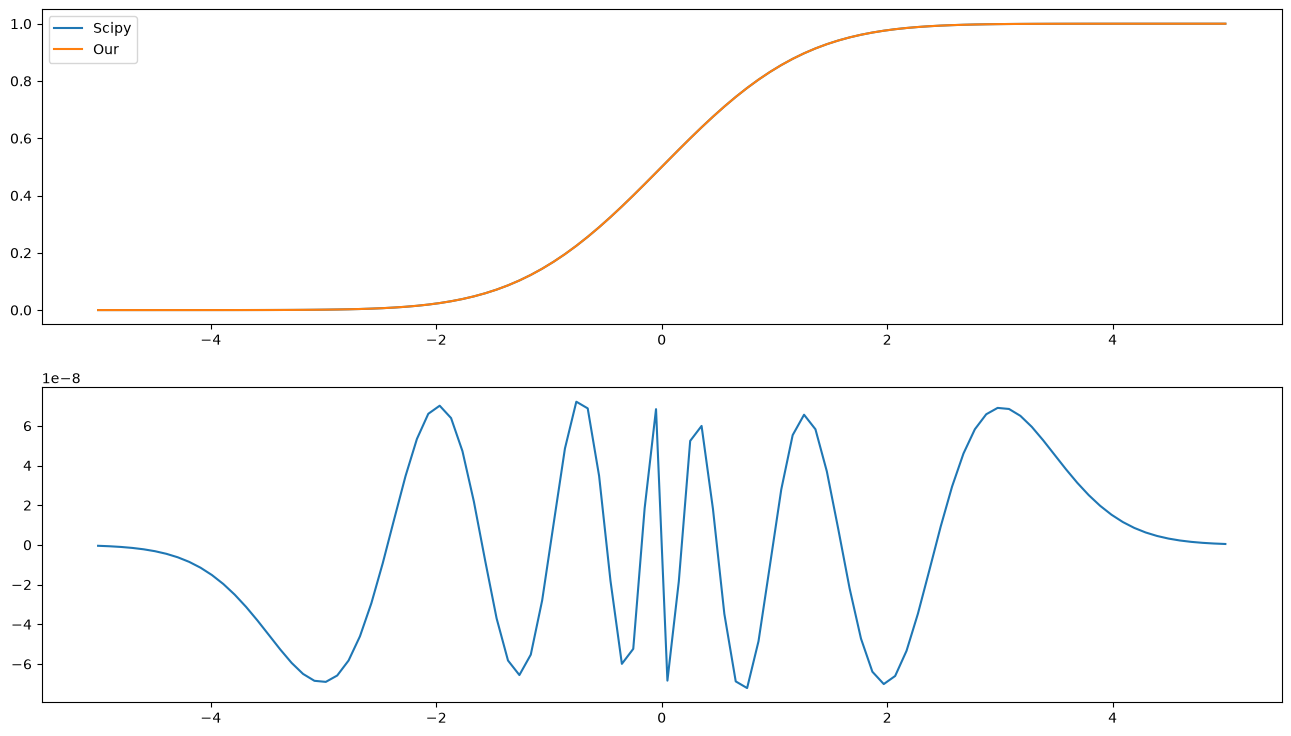

In [2]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-5,5,100)

fig, axs = plt.subplots(2, figsize=(16,9))

axs[0].plot(x, norm.cdf(x), label="Scipy")
axs[0].plot(x, [norm_cdf(j) for j in x], label="Our")
axs[0].legend()

axs[1].plot(x, norm.cdf(x)-np.array([norm_cdf(j) for j in x]))

# Prices

In [3]:
# Define quantities
S = 100
T = 1
q = 0.02
r = 0.05
d1 = 0.25
d2 = 0.05
sigma = 0.2
K = 100

# Compare
print(f"Call Price from function = {black_scholes_call(S, K, T, r, q, sigma)}   ;   Call Price from equation = {S*np.exp(-q*T)*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)}")

Call Price from function = 9.226993989361226   ;   Call Price from equation = 9.227005508154036


# Compare IVs with IVs from yfinance (Calls)

In [9]:
import yfinance as yf
from src.utils.time_utils import compute_time_to_expiry

# Get option chain and T
SPY = yf.Ticker("SPY")
exp_dates = SPY.options
T = compute_time_to_expiry(exp_dates[0])
opt = SPY.option_chain(exp_dates[0])

calls = opt.calls
puts = opt.puts

S = SPY.history(period="1d")['Close'].iloc[-1]
print(f"Price of underlying = {S}")

calls.head()

Price of underlying = 744.780029296875


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY260706C00625000,2026-07-02 14:39:40+00:00,625.0,123.71,117.82,121.34,1.769997,1.451531,30.0,31,1.182133,True,REGULAR,USD
1,SPY260706C00660000,2026-06-29 13:34:02+00:00,660.0,87.60,82.83,86.35,8.729996,11.068842,6.0,26,0.878175,True,REGULAR,USD
2,SPY260706C00665000,2026-07-02 19:57:29+00:00,665.0,80.06,77.83,81.35,10.049995,14.355085,2.0,0,0.834718,True,REGULAR,USD
3,SPY260706C00670000,2026-07-01 14:37:02+00:00,670.0,75.09,72.83,76.35,-1.910004,-2.480524,2.0,12,0.791018,True,REGULAR,USD
4,SPY260706C00700000,2026-07-02 19:57:25+00:00,700.0,45.14,42.84,46.36,-1.729999,-3.691059,122.0,5,0.527104,True,REGULAR,USD


In [23]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

# --- Compute our IVs and collect yfinance IVs ---
spot_price = SPY.history(period="1d")['Close'].iloc[-1]
T = compute_time_to_expiry(exp_dates[0])
r, q = 0.045, 0.012

results = []

# Process calls
for idx, row in calls.iterrows():
    strike = row['strike']
    last_price = row['lastPrice']
    yf_iv = row['impliedVolatility']
    
    if last_price <= 0 or yf_iv <= 0:
        continue
    
    our_iv = implied_volatility(
        price=last_price,
        S=spot_price,
        K=strike,
        T=T,
        r=r,
        q=q,
        option_type='call'
    )
    
    results.append({
        'strike': strike,
        'option_type': 'call',
        'our_iv': our_iv,
        'yf_iv': yf_iv
    })

# Process puts
for idx, row in puts.iterrows():
    strike = row['strike']
    last_price = row['lastPrice']
    yf_iv = row['impliedVolatility']
    
    if last_price <= 0 or yf_iv <= 0:
        continue
    
    our_iv = implied_volatility(
        price=last_price,
        S=spot_price,
        K=strike,
        T=T,
        r=r,
        q=q,
        option_type='put'
    )
    
    results.append({
        'strike': strike,
        'option_type': 'put',
        'our_iv': our_iv,
        'yf_iv': yf_iv
    })

df = pd.DataFrame(results).dropna(subset=['our_iv', 'yf_iv'])

# --- Plot: Subplots for Calls vs Puts ---
fig = make_subplots(
    rows=1, cols=2,
    shared_yaxes=True,
    subplot_titles=("Calls", "Puts"),
    horizontal_spacing=0.1
)

# Color scheme
colors = {'our': '#1f77b4', 'yf': '#ff7f0e'}

# Calls
calls_df = df[df['option_type'] == 'call']
fig.add_trace(
    go.Scatter(
        x=calls_df['strike'],
        y=calls_df['our_iv'],
        mode='markers',
        name='Our IV',
        marker=dict(color=colors['our'], size=8, symbol='circle'),
        legendgroup='our'
    ),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(
        x=calls_df['strike'],
        y=calls_df['yf_iv'],
        mode='markers',
        name='YFinance IV',
        marker=dict(color=colors['yf'], size=10, symbol='x'),
        legendgroup='yf'
    ),
    row=1, col=1
)

# Puts
puts_df = df[df['option_type'] == 'put']
fig.add_trace(
    go.Scatter(
        x=puts_df['strike'],
        y=puts_df['our_iv'],
        mode='markers',
        name='Our IV',
        marker=dict(color=colors['our'], size=8, symbol='circle'),
        legendgroup='our',
        showlegend=False
    ),
    row=1, col=2
)
fig.add_trace(
    go.Scatter(
        x=puts_df['strike'],
        y=puts_df['yf_iv'],
        mode='markers',
        name='YFinance IV',
        marker=dict(color=colors['yf'], size=10, symbol='x'),
        legendgroup='yf',
        showlegend=False
    ),
    row=1, col=2
)

fig.update_xaxes(title_text="Strike", row=1, col=1)
fig.update_xaxes(title_text="Strike", row=1, col=2)
fig.update_yaxes(title_text="Implied Volatility", row=1, col=1)

fig.update_layout(
    height=500,
    width=1000,
    title_text=f"IV Comparison (Spot = {spot_price:.2f}, T = {T:.4f} yrs)",
    hovermode='x unified'
)
fig.show()

# --- 3. Bonus: Parity Plot (Our IV vs YFinance IV) ---
fig2 = go.Figure()

fig2.add_trace(
    go.Scatter(
        x=df['yf_iv'],
        y=df['our_iv'],
        mode='markers',
        name='Data points',
        marker=dict(
            color=df['option_type'].map({'call': colors['our'], 'put': colors['yf']}),
            size=8,
            opacity=0.7
        ),
        text=[f"Strike: {s:.1f}, Type: {t}" for s, t in zip(df['strike'], df['option_type'])],
        hovertemplate='<b>%{text}</b><br>YF IV: %{x:.4f}<br>Our IV: %{y:.4f}<extra></extra>'
    )
)

# --- Summary Statistics ---
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
for opt_type in ['call', 'put']:
    sub = df[df['option_type'] == opt_type]
    if not sub.empty:
        diff = sub['our_iv'] - sub['yf_iv']
        print(f"\n{opt_type.capitalize()}s ({len(sub)} points):")
        print(f"  Mean difference: {diff.mean():.6f}")
        print(f"  Std deviation:   {diff.std():.6f}")
        print(f"  Max difference:  {diff.max():.6f}")
        print(f"  Min difference:  {diff.min():.6f}")

SUMMARY STATISTICS

Calls (70 points):
  Mean difference: 0.035409
  Std deviation:   0.052558
  Max difference:  0.315272
  Min difference:  -0.133568

Puts (66 points):
  Mean difference: 0.052446
  Std deviation:   0.085356
  Max difference:  0.697376
  Min difference:  -0.072689
